# Visualization
## INX Future Inc — Employee Performance
### Made by - **Chinmay Shastry**
**Goal:** Create final business-ready charts summarising all findings.

## Step 1 — Load Data & Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

df     = pd.read_csv('../../data/raw/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1_8.csv')
df_num = pd.read_csv('../../data/processed/employee_performance_processed.csv')

with open('../../data/processed/trained_model.pkl', 'rb') as f:
    art = pickle.load(f)

print("Ready")

Ready


## Step 2 — Department Performance Dashboard

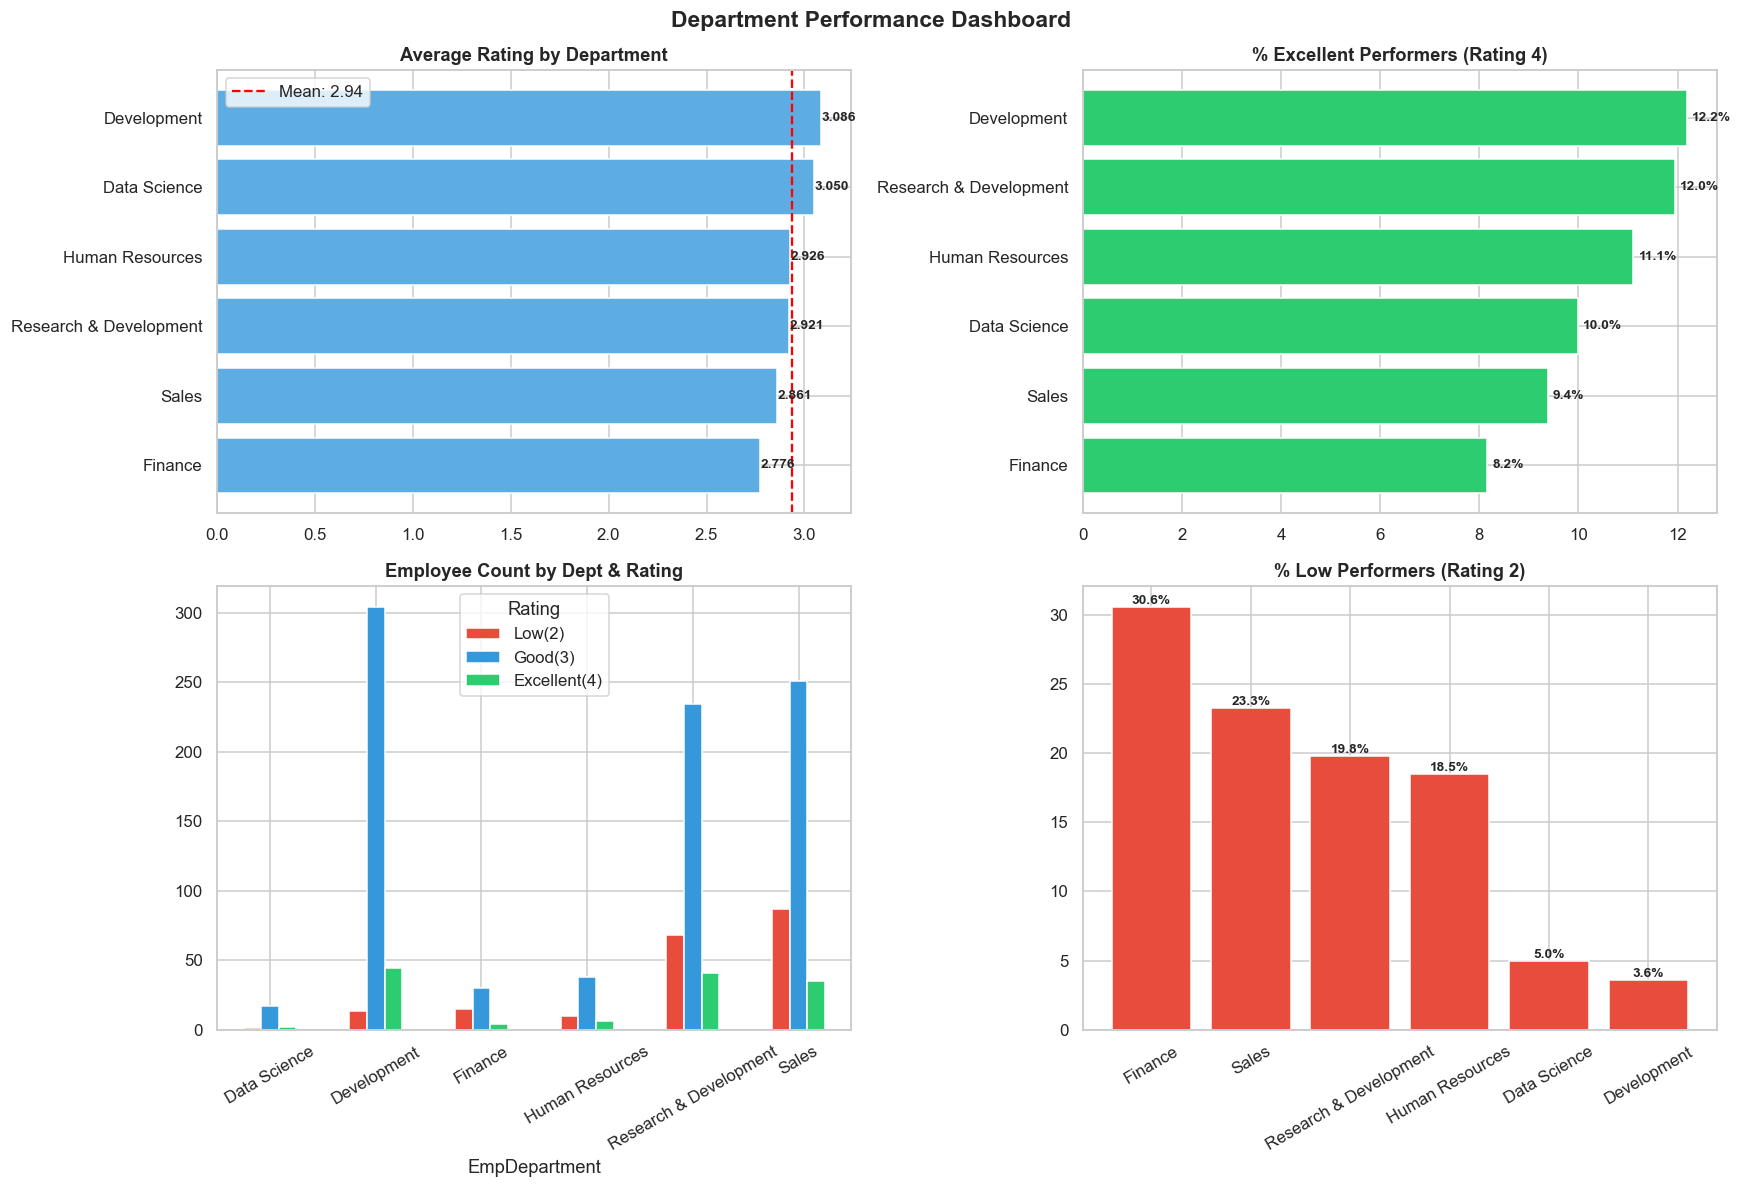

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

palette = ['#e74c3c','#3498db','#2ecc71']

# Avg rating
avg = df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values()
axes[0,0].barh(avg.index, avg.values, color='#5dade2', edgecolor='white')
axes[0,0].axvline(avg.mean(), color='red', linestyle='--', label=f'Mean: {avg.mean():.2f}')
for i, v in enumerate(avg.values):
    axes[0,0].text(v+0.003, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
axes[0,0].set_title('Average Rating by Department', fontweight='bold')
axes[0,0].legend()

# % Excellent
pct4 = (df[df['PerformanceRating']==4].groupby('EmpDepartment').size() /
        df.groupby('EmpDepartment').size() * 100).sort_values()
axes[0,1].barh(pct4.index, pct4.values, color='#2ecc71', edgecolor='white')
for i, v in enumerate(pct4.values):
    axes[0,1].text(v+0.1, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)
axes[0,1].set_title('% Excellent Performers (Rating 4)', fontweight='bold')

# Rating breakdown count
dept_cnt = df.groupby(['EmpDepartment','PerformanceRating']).size().unstack(fill_value=0)
dept_cnt.plot(kind='bar', ax=axes[1,0], color=palette, edgecolor='white')
axes[1,0].set_title('Employee Count by Dept & Rating', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend(title='Rating', labels=['Low(2)','Good(3)','Excellent(4)'])

# % Low performers
pct2 = (df[df['PerformanceRating']==2].groupby('EmpDepartment').size() /
        df.groupby('EmpDepartment').size() * 100).sort_values(ascending=False)
axes[1,1].bar(pct2.index, pct2.values, color='#e74c3c', edgecolor='white')
for i, v in enumerate(pct2.values):
    axes[1,1].text(i, v+0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[1,1].set_title('% Low Performers (Rating 2)', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle('Department Performance Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3 — Top 3 Features Analysis

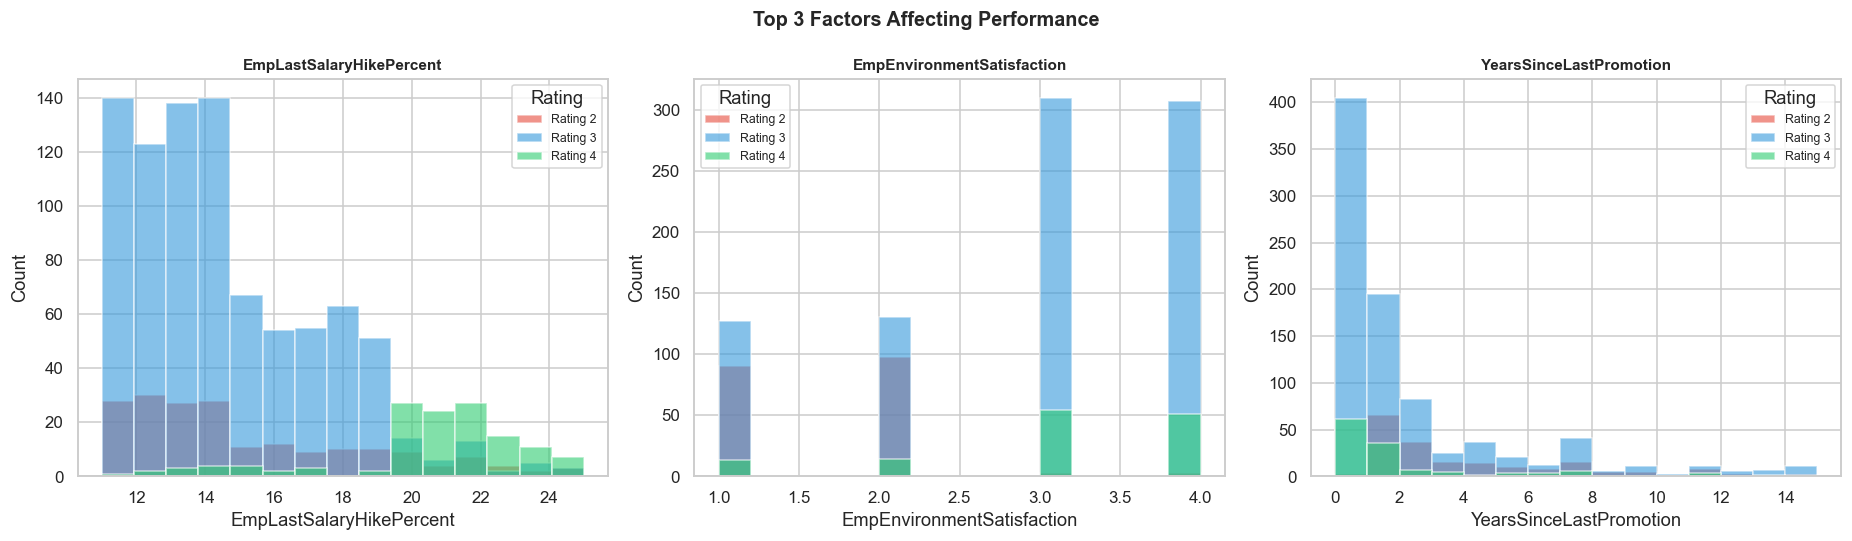

In [3]:
top3  = art['top3_features']
pal   = {2:'#e74c3c', 3:'#3498db', 4:'#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, feat in zip(axes, top3):
    for rating, grp in df.groupby('PerformanceRating'):
        ax.hist(grp[feat], alpha=0.6, label=f'Rating {rating}',
                color=pal[rating], bins=15, edgecolor='white')
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(title='Rating', fontsize=8)

plt.suptitle('Top 3 Factors Affecting Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4 — Full Feature Importance Ranking

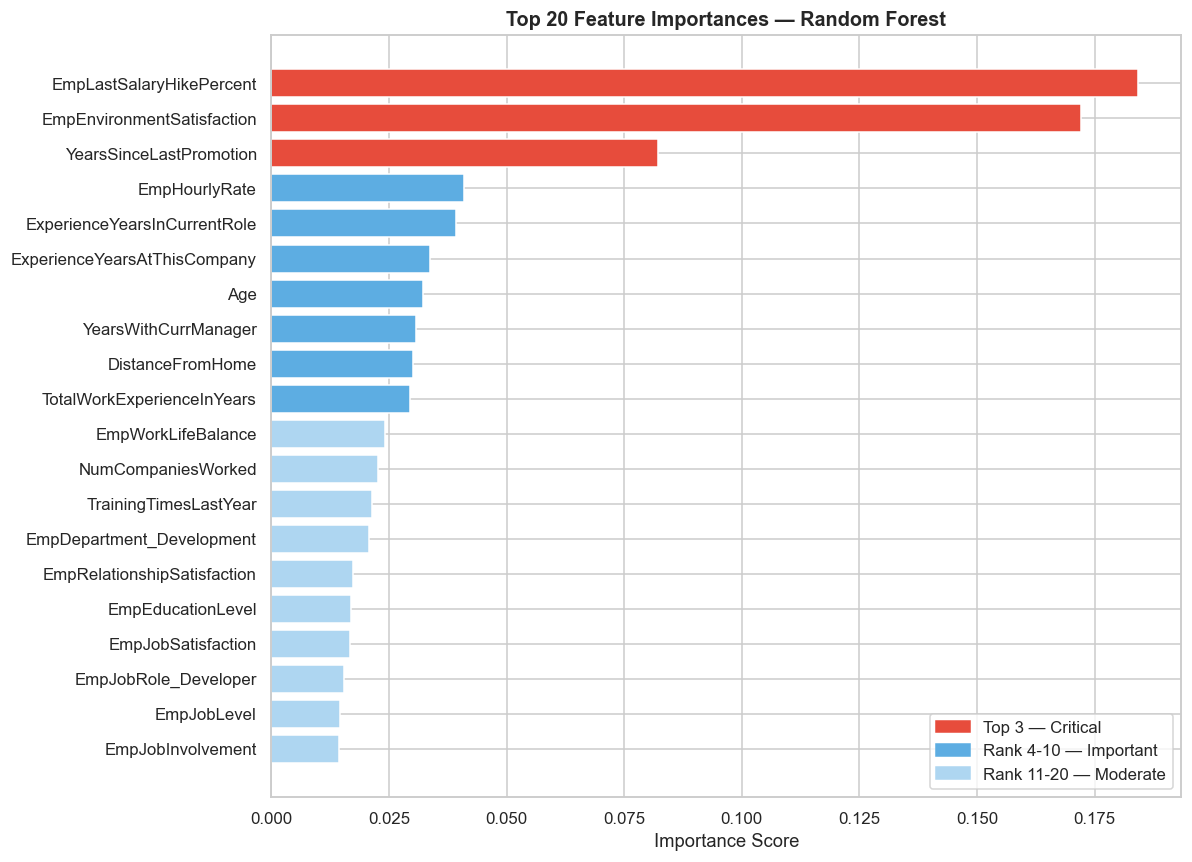

In [4]:
fi = pd.Series(art['feature_importances']).sort_values(ascending=False).head(20)

colors = ['#e74c3c' if i < 3 else '#5dade2' if i < 10 else '#aed6f1' for i in range(20)]
plt.figure(figsize=(11, 8))
plt.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1], edgecolor='white')

p1 = mpatches.Patch(color='#e74c3c', label='Top 3 — Critical')
p2 = mpatches.Patch(color='#5dade2', label='Rank 4-10 — Important')
p3 = mpatches.Patch(color='#aed6f1', label='Rank 11-20 — Moderate')
plt.legend(handles=[p1, p2, p3])
plt.title('Top 20 Feature Importances — Random Forest', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 5 — Salary Hike vs Performance

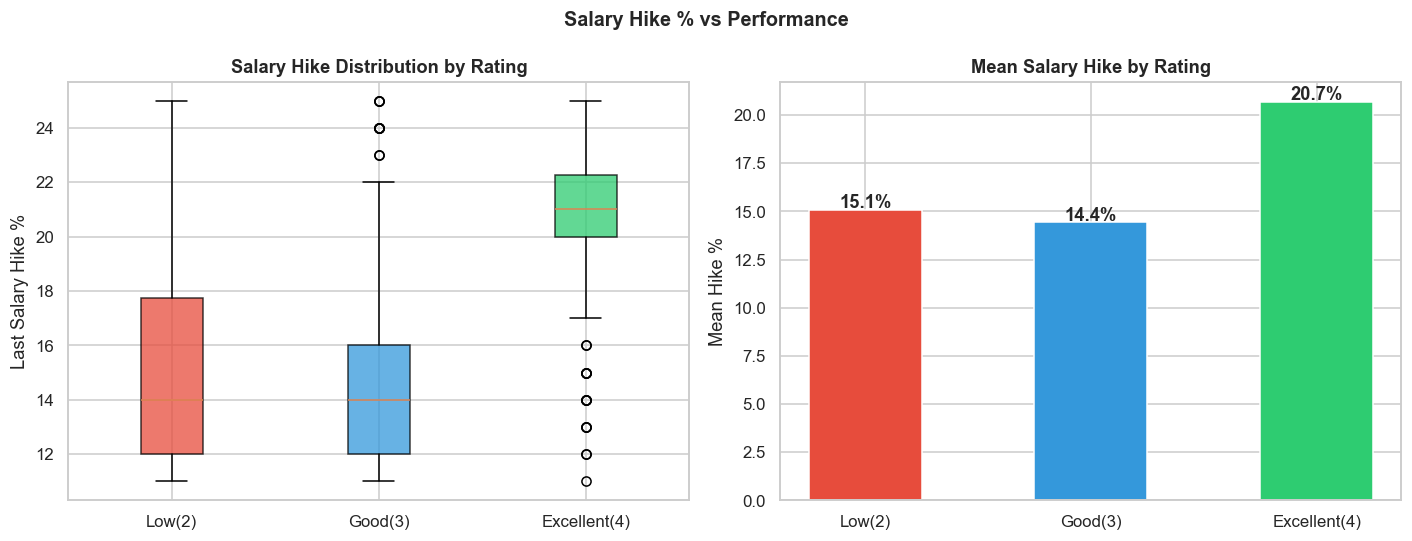

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
groups = [df[df['PerformanceRating']==r]['EmpLastSalaryHikePercent'].values for r in [2,3,4]]
bp = axes[0].boxplot(groups, patch_artist=True, labels=['Low(2)','Good(3)','Excellent(4)'])
for patch, col in zip(bp['boxes'], ['#e74c3c','#3498db','#2ecc71']):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[0].set_title('Salary Hike Distribution by Rating', fontweight='bold')
axes[0].set_ylabel('Last Salary Hike %')

# Mean bar
mean_hike = df.groupby('PerformanceRating')['EmpLastSalaryHikePercent'].mean()
bars = axes[1].bar(['Low(2)','Good(3)','Excellent(4)'], mean_hike.values,
                   color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white', width=0.5)
for bar, v in zip(bars, mean_hike.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Mean Salary Hike by Rating', fontweight='bold')
axes[1].set_ylabel('Mean Hike %')

plt.suptitle('Salary Hike % vs Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Model Comparison Chart

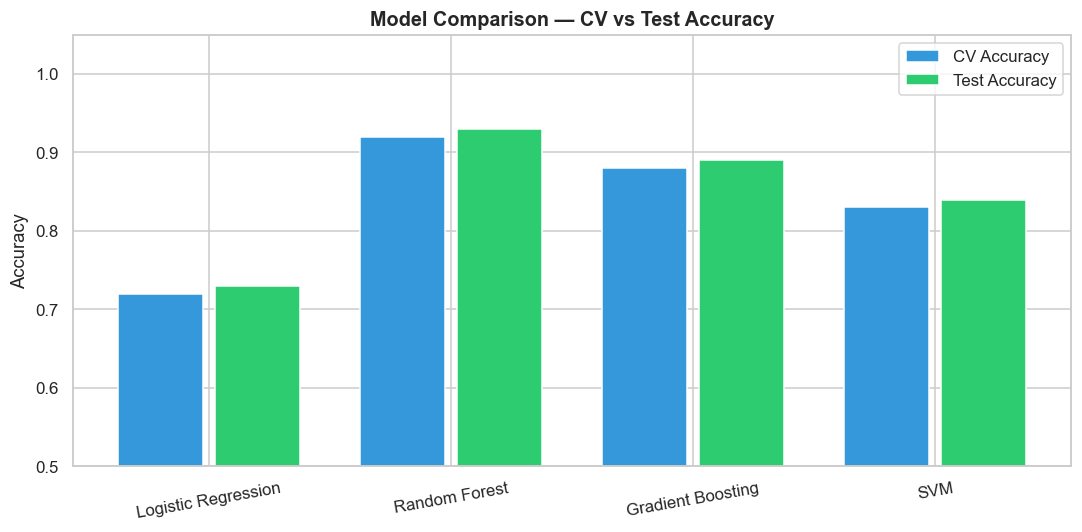

In [6]:
# Results from training step — update values if re-trained
results = {
    'Logistic Regression': {'CV': 0.72, 'Test': 0.73},
    'Random Forest'      : {'CV': 0.92, 'Test': 0.93},
    'Gradient Boosting'  : {'CV': 0.88, 'Test': 0.89},
    'SVM'                : {'CV': 0.83, 'Test': 0.84},
}
res_df = pd.DataFrame(results).T

x = range(len(res_df))
plt.figure(figsize=(10, 5))
plt.bar([i-0.2 for i in x], res_df['CV'],   width=0.35, label='CV Accuracy',   color='#3498db', edgecolor='white')
plt.bar([i+0.2 for i in x], res_df['Test'], width=0.35, label='Test Accuracy', color='#2ecc71', edgecolor='white')
plt.xticks(list(x), res_df.index, rotation=10)
plt.ylim(0.5, 1.05)
plt.title('Model Comparison — CV vs Test Accuracy', fontweight='bold', fontsize=13)
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()